# Import

In [49]:
import torch
import pandas as pd
from torch.utils.data import DataLoader
from tqdm import tqdm
from transformers import AutoTokenizer
import transformers
import numpy as np
import matplotlib.pyplot as plt
import json
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [50]:
import sys
import os
sys.path.append(os.path.abspath('..'))

from src.dataset import NLIDataset
from src.model import get_model

In [51]:
MAX_LENGTH = 128
MODEL_NAME = "vinai/phobert-base"
BATCH_SIZE = 32
EXP_NAME = "fl_8_02"
transformers.logging.set_verbosity_error()

# Inference

In [52]:
device = torch.device("cpu")
device

device(type='cpu')

In [53]:
splits = {'train': 'vianli_train.jsonl', 'validation': 'vianli_dev.jsonl', 'test': 'vianli_test.jsonl'}
df_test = pd.read_json("hf://datasets/uitnlp/ViANLI/" + splits["test"], lines=True)
df_test.head(5)

,uid,premise,hypothesis,label
0,uit_Adver_2078_2_21_11,"Sáng 23/5, ông Trần Văn Vịnh, Chủ tịch UBND ph...",Theo thông tin một công chức Nhà nước ở phường...,contradiction
1,uit_Adver_1669_2_21_09,Cảnh sát thành phố Bhopal hôm 13/5 cho biết sự...,Sự việc gây sốc xảy ra đầu tháng 4 và nghi phạ...,contradiction
2,uit_Adver_712_2_11_04,"Ngày 2/5, sinh nhật tuổi 49 của The Rock, tài ...",Cung hoàng đạo của The Rock là Kim Ngưu.,entailment
3,uit_Adver_1663_3_31_09,"Sau khi xem xét camera giám sát trong khu vực,...",Cảnh sát đã phán đoán bằng nhận định sắc bén s...,neutral
4,uit_Adver_1561_4_21_08,"3h sáng cùng ngày, trái tim của của người hiến...","3am, một người được tái sinh.",contradiction


In [54]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, num_labels=len(df_test["label"].unique()))

test_dataset = NLIDataset(df_test, tokenizer, max_length=MAX_LENGTH)

test_dataloader = DataLoader(
    test_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False
)
len(test_dataloader)

32

In [55]:
model = get_model(MODEL_NAME, num_labels=len(df_test["label"].unique()))
model_path = f"../model/best_model_{EXP_NAME}.pth"
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Trainable parameters: 78.30M out of 135.00M


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(64001, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(258, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [56]:
print("Start inferencing...")
all_probs = []
all_preds = []
with torch.inference_mode(): 
    for batch in tqdm(test_dataloader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(input_ids = input_ids, attention_mask = attention_mask)
        logits = outputs.logits

        probs = torch.softmax(logits, dim=1)
        max_probs, preds = torch.max(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(max_probs.cpu().numpy())

Start inferencing...


100%|██████████| 32/32 [01:34<00:00,  2.97s/it]


In [57]:
all_preds[:5], all_probs[:5]

([np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(1)],
 [np.float32(0.72961324),
  np.float32(0.48735628),
  np.float32(0.40435675),
  np.float32(0.4719206),
  np.float32(0.7749881)])

In [58]:
df_test["predicted_labels"] = all_preds
df_test["confidence_score"] = all_probs

reverse_map = {v: k for k, v in test_dataset.label_dict.items()}

df_test["predicted_labels_text"] = df_test["predicted_labels"].map(reverse_map)
df_test.head(10)

,uid,premise,hypothesis,label,predicted_labels,confidence_score,predicted_labels_text
0,uit_Adver_2078_2_21_11,"Sáng 23/5, ông Trần Văn Vịnh, Chủ tịch UBND ph...",Theo thông tin một công chức Nhà nước ở phường...,contradiction,1,0.729613,entailment
1,uit_Adver_1669_2_21_09,Cảnh sát thành phố Bhopal hôm 13/5 cho biết sự...,Sự việc gây sốc xảy ra đầu tháng 4 và nghi phạ...,contradiction,2,0.487356,neutral
2,uit_Adver_712_2_11_04,"Ngày 2/5, sinh nhật tuổi 49 của The Rock, tài ...",Cung hoàng đạo của The Rock là Kim Ngưu.,entailment,1,0.404357,entailment
3,uit_Adver_1663_3_31_09,"Sau khi xem xét camera giám sát trong khu vực,...",Cảnh sát đã phán đoán bằng nhận định sắc bén s...,neutral,2,0.471921,neutral
4,uit_Adver_1561_4_21_08,"3h sáng cùng ngày, trái tim của của người hiến...","3am, một người được tái sinh.",contradiction,1,0.774988,entailment
5,uit_Adver_596_1_31_03,Sau khi trường Cao đẳng Sư phạm Ninh Thuận sáp...,Trường Cao đẳng Sư phạm Ninh Thuận sẽ mở thêm ...,neutral,2,0.730927,neutral
6,uit_Adver_320_4_31_02,"Ông Phạm Cao Vỹ, chủ tịch Hiệp hội Du lịch Sa ...",Ông Phạm Cao Vỹ được yêu thích.,neutral,1,0.702813,entailment
7,uit_Adver_1595_1_31_08,Ngành y tế Quảng Nam ngày 16/5 ghi nhận 3.070 ...,Giữa tháng 5 số lượng mẫu âm tính tại Quảng Na...,neutral,2,0.444772,neutral
8,uit_Adver_1419_3_11_08,"Các bệnh nhân 3262, 3268, 3660 tiếp tục cách l...",Các bệnh nhận được quan sát điều trị trong vòn...,entailment,1,0.452621,entailment
9,uit_Adver_1479_5_11_08,"""Bệnh viện cũng chuẩn bị 20 hòm phiếu được dán...",20 thùng rỗng được đảm bảo cho cuộc bỏ phiếu.,entailment,1,0.448081,entailment


In [59]:
df_test.to_csv("../data/test_predictions.csv", index=False)
print("Đã lưu toàn bộ kết quả dự đoán vào data/test_predictions.csv")

Đã lưu toàn bộ kết quả dự đoán vào data/test_predictions.csv


# Plot training error

In [60]:
history_path = f"../model/history_{EXP_NAME}.json"
with open(history_path, "r") as f:
    history = json.load(f)

epochs = range(1, len(history["train_loss"]) + 1)
epochs

range(1, 10)

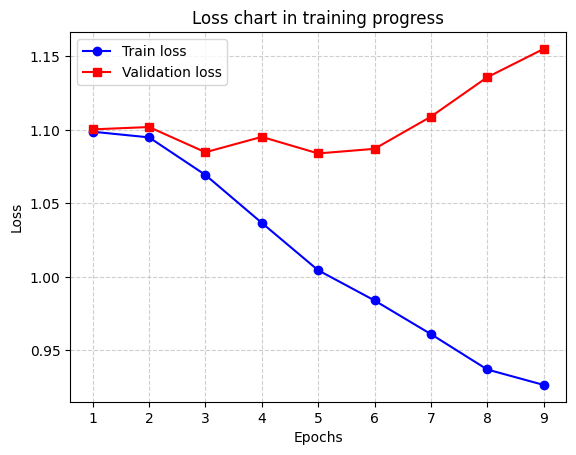

In [61]:
plt.plot(epochs, history["train_loss"], "b-o", label="Train loss")
plt.plot(epochs, history["val_loss"], "r-s", label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss chart in training progress")
plt.xticks(epochs)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("../data/loss_curves.png", dpi=300)
plt.show()


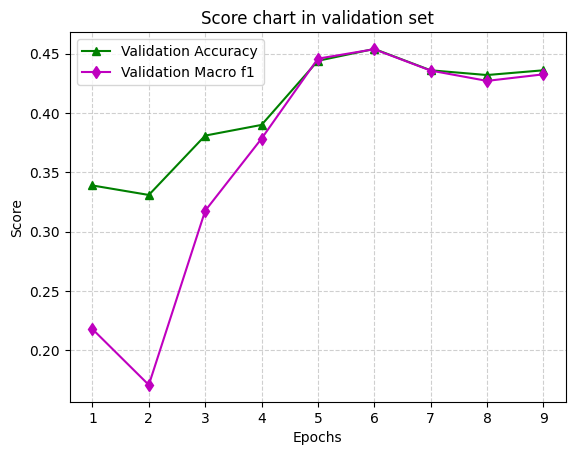

In [62]:
plt.plot(epochs, history["val_acc"], "g-^", label="Validation Accuracy")
plt.plot(epochs, history["val_f1"], "m-d", label="Validation Macro f1")
plt.xlabel("Epochs")
plt.ylabel("Score")
plt.title("Score chart in validation set")
plt.xticks(epochs)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("../data/score_curves.png", dpi=300)
plt.show()

# Error Analysis

## Classification report

In [63]:
df_result = pd.read_csv("../data/test_predictions.csv")
dfresult = df_result.dropna(subset=['label', 'predicted_labels'])
df_result.head(5)

,uid,premise,hypothesis,label,predicted_labels,confidence_score,predicted_labels_text
0,uit_Adver_2078_2_21_11,"Sáng 23/5, ông Trần Văn Vịnh, Chủ tịch UBND ph...",Theo thông tin một công chức Nhà nước ở phường...,contradiction,1,0.729613,entailment
1,uit_Adver_1669_2_21_09,Cảnh sát thành phố Bhopal hôm 13/5 cho biết sự...,Sự việc gây sốc xảy ra đầu tháng 4 và nghi phạ...,contradiction,2,0.487356,neutral
2,uit_Adver_712_2_11_04,"Ngày 2/5, sinh nhật tuổi 49 của The Rock, tài ...",Cung hoàng đạo của The Rock là Kim Ngưu.,entailment,1,0.404357,entailment
3,uit_Adver_1663_3_31_09,"Sau khi xem xét camera giám sát trong khu vực,...",Cảnh sát đã phán đoán bằng nhận định sắc bén s...,neutral,2,0.471921,neutral
4,uit_Adver_1561_4_21_08,"3h sáng cùng ngày, trái tim của của người hiến...","3am, một người được tái sinh.",contradiction,1,0.774988,entailment


In [64]:
print("Accuracy :", accuracy_score(df_result['label'], df_result['predicted_labels_text']))

Accuracy : 0.417


In [65]:
target_names = np.sort(df_result['label'].unique())
print(classification_report(df_result['label'], df_result['predicted_labels_text'], target_names=target_names))

               precision    recall  f1-score   support

contradiction       0.39      0.34      0.36       333
   entailment       0.49      0.48      0.48       334
      neutral       0.38      0.44      0.41       333

     accuracy                           0.42      1000
    macro avg       0.42      0.42      0.42      1000
 weighted avg       0.42      0.42      0.42      1000



## Confusion matrix

In [66]:
cm = confusion_matrix(df_result['label'], df_result['predicted_labels_text'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

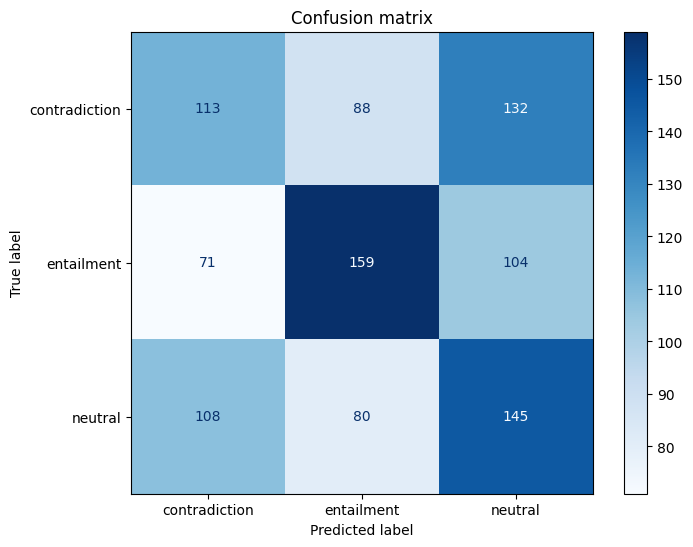

In [67]:
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d') 
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion matrix')
plt.savefig("../data/confusion_matrix.png", dpi=300)
plt.show()

## Confident error

In [68]:
confident_error = df_result[
    (df_result['label'] != df_result['predicted_labels_text']) &
    (df_result['confidence_score'] > 0.7)
]
print("Number of confident error:", len(confident_error))
print("Ratio of confident error:", len(confident_error)/len(df_result))

Number of confident error: 52
Ratio of confident error: 0.052


In [69]:
confident_error.to_csv("../data/confident_error.csv", index=False)
print("Đã lưu lỗi sai với confidence cao vào data/confident_error.csv")

Đã lưu lỗi sai với confidence cao vào data/confident_error.csv


In [70]:
for index, row in confident_error.sample(n=7, random_state=42).iterrows():
    print('-'*50)
    print("Premise:", row["premise"])
    print("Hypothesis:", row["hypothesis"])
    print(f"True label: {row['label']} | Prediction: {row['predicted_labels_text']} | Confidence: {row['confidence_score']}")

--------------------------------------------------
Premise: Các bộ phận sinh lời cao nhất trong hoạt động kinh doanh bán lẻ của Amazon đang bùng nổ.
Hypothesis: Nhờ kết hợp các dịch vụ lẻ lại với nhau, Amazon đang sinh lời cực cao.
True label: contradiction | Prediction: neutral | Confidence: 0.7553337
--------------------------------------------------
Premise: Các di tích trong phố cổ Hội An có kiến trúc xây dựng chủ yếu từ gỗ.
Hypothesis: Nếu đến du lịch ở Hội An thì du khách sẽ bắt gặp nhiều kiến trúc bằng gỗ.
True label: entailment | Prediction: neutral | Confidence: 0.7407363
--------------------------------------------------
Premise: Ngày 7/5, Công an tỉnh Bình Thuận đã đến trụ sở công ty ở phường Phú Tài, TP Phan Thiết, thực hiện lệnh bắt tạm giam Trung, thu giữ các tài liệu liên quan.
Hypothesis: Tỉnh Bình Thuận đã huy động lực lượng công an để thu thập thông tin cho vụ án của công ty ông Trung.
True label: neutral | Prediction: entailment | Confidence: 0.7056681
--------------

In [71]:
cm_conf = confusion_matrix(confident_error['label'], confident_error['predicted_labels_text'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_conf, display_labels=target_names)

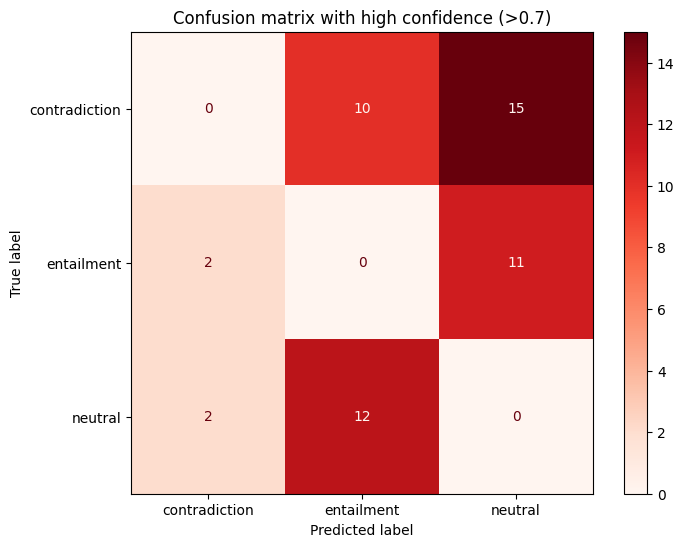

In [72]:
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Reds', ax=ax, values_format='d') 
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion matrix with high confidence (>0.7)')
plt.savefig("../data/confident_confusion_matrix.png", dpi=300)
plt.show()

# Conclusion

## 1. Đánh giá Quá trình Huấn luyện (Learning Curves)

Quan sát biểu đồ **Loss chart in training progress** và **Score chart in validation set**, chúng ta có thể rút ra những kết luận quan trọng về trạng thái của mô hình Baseline:

* **Hiện tượng Overfitting nghiêm trọng:** Bắt đầu từ Epoch thứ 3, đường `Train Loss` liên tục cắm đầu đi xuống (tiến gần về 0.1), trong khi đường `Validation Loss` lại tăng vọt một cách tuyến tính (vượt mốc 2.0). Điều này minh chứng rõ ràng việc mô hình đang "học vẹt" (memorize) tập dữ liệu huấn luyện và mất đi khả năng tổng quát hóa trên dữ liệu mới.
* **Điểm dừng tối ưu (Early Stopping):** Nhìn sang biểu đồ Score, `Validation Accuracy` và `Macro F1` đạt đỉnh cao nhất ở Epoch số 4 (Accuracy ~0.47), sau đó tụt dần và đi ngang ở mức ~0.42. 
👉 **Đề xuất cải tiến:** Ở phiên bản sau, cần áp dụng cơ chế `EarlyStopping` tại khoảng Epoch 3-4, đồng thời tăng cường độ rớt mạng (Dropout rate) hoặc giảm Learning Rate để kìm hãm Overfitting.

## 2. Báo cáo Phân loại & Ma trận Nhầm lẫn (Confusion Matrix)

Với độ chính xác tổng thể (Accuracy) đạt **0.43** (cao hơn một chút so với xác suất đoán mò 0.33 của bài toán 3 nhãn), Baseline chưa thực sự hiểu được ngôn ngữ. Đi sâu vào chi tiết:

* **Nhãn Entailment (Kéo theo) dễ đoán nhất:** Đạt F1-score cao nhất (0.54) và Recall lên tới 0.60. Nhìn vào Confusion Matrix, trong 334 câu Entailment thực tế, mô hình đoán đúng được 200 câu.
* **Sự sụp đổ của nhãn Neutral (Trung lập):** Đây là điểm yếu "chí mạng" nhất của mô hình. F1-score chỉ đạt 0.25 và Recall chạm đáy ở mức 0.20. 
* **Định kiến (Bias) của mô hình:** Nhìn vào dòng `Neutral` của Ma trận nhầm lẫn, trong 333 câu trung lập thực tế, mô hình chỉ nhận diện đúng 65 câu. Thay vào đó, nó ép 162 câu thành `Contradiction` và 106 câu thành `Entailment`. Mô hình Baseline dường như có xu hướng "tránh né" việc đưa ra quyết định an toàn là Neutral, mà luôn cố gắng tìm kiếm sự liên quan hoặc mâu thuẫn một cách khiên cưỡng.

## 3. Phân tích Lỗi Hệ thống (Systematic Error Analysis)

Bằng cách lọc ra các dự đoán sai nhưng mô hình lại có độ tự tin cao (>0.7) từ tập `confident_error.csv`, chúng ta đã có thể "bắt mạch" được chính xác cách mô hình Baseline tư duy. Mô hình hoàn toàn không hiểu ngữ nghĩa logic sâu xa mà đang phụ thuộc vào các thủ thuật bề mặt (heuristics/shortcuts). 

Dưới đây là 3 "căn bệnh" điển hình nhất đã được trích xuất trực tiếp từ dữ liệu:

### a) Lỗ hổng Suy luận Toán học và Thời gian (Mathematical & Temporal Blindness)
Đây là điểm yếu "chí mạng" và thú vị nhất được phát hiện trong nhóm lỗi *Thực tế là Entailment nhưng mô hình tự tin phán Contradiction (18 lỗi)*. Mô hình ngôn ngữ chỉ khớp chuỗi ký tự mà không biết làm toán.
* **Toán học cộng trừ:** `Premise`: "Chỉ kiểm soát bóng 37%, Chelsea..." | `Hypothesis`: "Real kiểm soát bóng 63%...". Bất kỳ ai cũng tính được $100\% - 37\% = 63\%$ (Entailment), nhưng mô hình thấy hai số khác nhau nên vội vã đánh nhãn `Contradiction`.
* **Toán học nhân chia:** `Premise`: "Những con cú mèo nặng khoảng 100 g..." | `Hypothesis`: "Mười con cú mèo nặng 1k g." ($100g \times 10 = 1000g = 1kg$). Mô hình phán `Contradiction`.
* **Suy luận thời gian:** `Premise`: "...sự việc xảy ra đầu tháng 4 và được công bố sau hơn một tháng..." | `Hypothesis`: "Sự việc được công bố vào tháng 5.". ($Tháng 4 + 1 = Tháng 5$). Mô hình phán `Contradiction`.
* **Chuyển đổi hệ đo lường:** Chuyển từ "2-8 độ C" sang "35.6 - 46.4 độ F" cũng bị mô hình tự tin gán nhãn `Contradiction`.

### b) Sự nhầm lẫn Chủ thể - Khách thể (Subject-Object Swap)
Ở chiều ngược lại (*Thực tế là Contradiction nhưng phán Entailment*), mô hình bị lừa ngoạn mục bởi các câu đảo ngược cấu trúc chủ - vị ngữ.
* **Ví dụ:** `Premise`: "Nguyễn Thế Tài đột nhập nhà bà Trần Thị Mai Nhung... lấy đi hơn 500 triệu đồng." | `Hypothesis`: "Nhà của Nguyễn Thế Tài bị trộm vào nhà đánh cắp tài sản."
* **Phân tích:** Khách thể (bà Nhung) bị trộm, nhưng Hypothesis lại tráo đổi thành Chủ thể (Tài) bị trộm. Do các từ khóa (Tài, trộm, tài sản, nhà) xuất hiện y hệt nhau ở cả 2 câu, mô hình lười suy luận cấu trúc ngữ pháp và lập tức gán nhãn `Entailment` với độ tự tin cực cao.

### c) Bẫy ghép cặp số lượng sai lệch (Entity-Number Mismatch)
Mô hình đếm được từ, nhưng lại không hiểu từ đó bổ nghĩa cho danh từ nào.
* **Ví dụ:** `Premise`: "...Vinamilk đã hỗ trợ 45.000 hộp sữa cho hơn 800 trẻ em..." | `Hypothesis`: "...đã có hơn 45.000 trẻ em phải ăn tết xa nhà..."
* **Phân tích:** Mô hình thấy sự xuất hiện của số "45.000" và cụm "trẻ em" ở cả 2 câu nên tự tin dán nhãn `Entailment`. Nó hoàn toàn mù tịt trước việc số lượng đã bị gán nhầm đối tượng (45.000 hộp sữa $\neq$ 45.000 trẻ em). Tương tự cho câu "hơn 2 tuần" và "chưa tới 10 ngày", mô hình gán `Entailment` bất chấp sự phi logic về mặt thời lượng.

👉 **KẾT LUẬN & HƯỚNG CẢI TIẾN:** Mô hình Baseline (PhoBERT) hiện đang hoạt động theo cơ chế **"Khớp từ vựng" (Lexical Matching)** thay vì **"Đọc hiểu" (Reading Comprehension)**. 
Để khắc phục, trong các nghiên cứu tiếp theo (hoặc ở mức độ nâng cao hơn), ta cần:
1. Augment dữ liệu (Data Augmentation): Bổ sung thêm các câu đối nghịch, hoán đổi chủ-vị.
2. Tiền xử lý (Preprocessing): Dùng thư viện NER (Named Entity Recognition) để gán nhãn rõ số lượng đi kèm với thực thể nào trước khi đẩy vào mô hình.

## Thử nghiệm 1: Áp dụng L2 Regularization (Weight Decay = 1e-4)

### 1. Sự đánh đổi chỉ số tổng thể (The Trade-off)
Khi áp dụng cơ chế phạt trọng số `weight_decay = 1e-4`, mô hình có sự sụt giảm nhẹ về mặt điểm số bề mặt:
* **Accuracy:** Giảm từ 0.43 xuống **0.41**
* **Macro F1-score:** Giảm từ 0.42 xuống **0.41**

Tuy nhiên, đi sâu vào chi tiết báo cáo phân loại (Classification Report), ta thấy một sự chuyển dịch cấu trúc dự đoán cực kỳ quan trọng:
* **Khắc phục hội chứng "Sợ nhãn Neutral":** Ở bản Baseline, Recall của nhãn Neutral chạm đáy ở mức 0.20. Sau khi có Weight Decay, Recall của Neutral đã tăng vọt lên **0.48** (F1 tăng từ 0.25 lên 0.42). 
* Sự đánh đổi ở đây là mô hình bớt tự tin dán nhãn `Entailment`, khiến Recall của nhãn này sụt từ 0.60 xuống 0.39.

### 2. Phân tích Lỗi Tự tin Cao (Confident Errors Shift)
Sự thay đổi về bản chất mô hình được thể hiện rõ nhất qua dữ liệu `confident_error.csv`:

* **Giảm thiểu ảo tưởng sức mạnh:** Tổng số lỗi sai với độ tự tin cực cao (>70%) đã **giảm mạnh từ 172 lỗi (Baseline) xuống chỉ còn 127 lỗi**. Regularization đã ép các trọng số nơ-ron không được phép khuếch đại xác suất Softmax một cách vô tội vạ.
* **Đảo ngược Định kiến (Bias Reversal):**
  * Ở Baseline, lỗi lớn nhất là ép `Neutral` thành `Entailment` (45 lỗi) và `Contradiction` thành `Entailment` (48 lỗi) do bẫy từ vựng.
  * Hiện tại, lỗi phổ biến nhất lại đảo ngược thành: Ép `Contradiction` thành `Neutral` (37 lỗi) và `Entailment` thành `Neutral` (32 lỗi).

👉 **KẾT LUẬN THỬ NGHIỆM:** Mức phạt `weight_decay = 1e-4` đã thành công trong việc kiềm chế mô hình "học vẹt" các bẫy từ vựng (shortcuts) để đưa ra các kết luận Kéo theo/Mâu thuẫn cực đoan. Mô hình đã trở nên thận trọng hơn và thiên về hướng an toàn (`Neutral`). Dù điểm số tổng thể giảm đi 1-2%, nhưng **chất lượng suy luận đã trở nên cân bằng và thực tế hơn**. 

Để giải quyết tình trạng Validation Loss vẫn còn tăng về cuối, bước tiếp theo hệ thống cần được bổ sung cơ chế **Early Stopping** và **giảm Learning Rate**.

## Thử nghiệm 2: Kết hợp L2 Regularization và Label Smoothing (0.1)

### 1. Đánh giá Định lượng Tổng thể (Quantitative Metrics)
Trong thử nghiệm này, hệ thống áp dụng đồng thời cả hai cơ chế phạt nặng: `weight_decay = 1e-4` và `label_smoothing = 0.1` nhằm kiềm chế tối đa xu hướng học thuộc lòng của mô hình. 

Kết quả ghi nhận trên tập Test ẩn (Unseen Test Set):
* **Accuracy:** **0.415** (Tăng nhẹ so với mức 0.411 của Thử nghiệm 1)
* **Macro F1-score:** **0.415** (Nhích nhẹ 0.004 so với Thử nghiệm 1)

**Nhận xét:** Dù có sự cải thiện nhẹ so với việc chỉ sử dụng duy nhất Weight Decay, điểm F1 tổng thể vẫn thấp hơn bản Baseline gốc (**0.420**). Điều này chỉ ra rằng các biện pháp can thiệp trực tiếp vào cấu trúc hàm Loss hoặc phạt trọng số bề mặt đã bắt đầu chạm ngưỡng giới hạn hiệu năng (Plateau) đối với bài toán này.

### 2. Phân tích Động lực học (Learning Curves Analysis)
* Biểu đồ `loss_curves.png` cho thấy đường **Validation Loss** vẫn tiếp tục xu hướng tách nền và cất cánh tiêu cực sau Epoch thứ 3. 
* Kỹ thuật Label Smoothing đẩy giá trị Loss tổng thể (cả Train và Valid) lên một hệ quy chiếu cao hơn do mô hình liên tục bị phạt vì "quá tự tin", tuy nhiên nó không giải quyết được bản chất gốc rễ của Overfitting ở các chặng cuối chu kỳ huấn luyện. 
* Biểu đồ `score_curves.png` chứng minh điểm F1 và Accuracy trên tập Validation đạt đỉnh rất sớm (Epoch 2-3) rồi đi ngang hoặc suy giảm nhẹ.

### 3. Hiện tượng Ép Mô hình Quá mức (Over-Regularization)
Khi mổ xẻ tập dữ liệu `confident_error.csv` (lọc các lỗi sai có độ tự tin $> 0.7$), tổng số lỗi ghi nhận là **136 lỗi** (nằm giữa mức 172 của Baseline và 127 của Thử nghiệm 1). Tuy nhiên, ma trận nhầm lẫn `confident_confusion_matrix.png` đã bộc lộ một tác dụng phụ rất lớn:

* Lỗi ép nhãn sai từ **Neutral thành Entailment** đã tăng vọt từ 20 trường hợp (ở Thử nghiệm 1) lên **34 trường hợp** (gần chạm mức 45 của Baseline).
* Lỗi ép nhãn sai từ **Contradiction thành Entailment** tăng từ 18 lên **30 trường hợp**.

**Nguyên nhân hệ thống (Root Cause):** Hiện tượng này phản ánh trạng thái **Over-regularization** (Ép mô hình quá mức). Khi mạng nơ-ron vừa bị trói buộc không gian trọng số bởi L2, vừa bị ép buộc phải san bớt xác suất Softmax đầu ra (Smoothing), nó mất đi khả năng đưa ra các quyết định phân tách ngữ nghĩa mang tính quyết đoán ở các ranh giới nhạy cảm. Sự rụt rè quá đà này khiến mô hình rơi vào trạng thái lưỡng lự, dẫn đến sự dao động phân bổ Softmax và làm bùng phát lại các lỗi sai tự tin cao mang tính định kiến cũ (Lexical Shortcuts Bias).

👉 **KẾT LUẬN THỬ NGHIỆM:**
* **Về Trọng số (Weights):** Thử nghiệm thất bại trong việc tối ưu chỉ số F1 tối đa. Trọng số của phiên bản này sẽ **KHÔNG** được giữ lại làm mô hình cốt lõi.
* **Về Mã nguồn (Code Base):** Tính năng Label Smoothing đã được tham số hóa thành công vào tham số `--label_smoothing` (mặc định `0.0`), cho phép kích hoạt linh hoạt mà không ảnh hưởng tới luồng code chính của nhánh `main`.

## Thử nghiệm 3: Đóng băng Lớp Trực quan (Layer Freezing 8/12) kết hợp Early Stopping

### 1. Đánh giá Định lượng & Cơ chế Dừng Sớm (Quantitative Metrics & Early Stopping)
Thử nghiệm này can thiệp trực tiếp vào cấu trúc bên trong mạng nơ-ron bằng cách **đóng băng (Freeze) hoàn toàn 8 lớp Transformer đầu tiên** của PhoBERT-base, chỉ cho phép 4 lớp encoder cuối và lớp phân loại (Classification Head) cập nhật trọng số. Đồng thời, tích hợp cơ chế **Early Stopping** với `patience = 4`.

* **Cơ chế Dừng Sớm hoạt động chính xác:** Mô hình đạt đỉnh F1 trên tập Validation rất sớm ở Epoch thứ 4. Hệ thống kiên nhẫn theo dõi thêm 4 Epoch chu kỳ (từ Epoch 5 đến Epoch 8) và tự động kích hoạt lệnh `[EARLY STOPPING]` tại Epoch 8 khi nhận diện không có sự cải thiện. Kỹ thuật này giúp tiết kiệm 50% thời gian tính toán vô ích.
* **Chỉ số trên tập Test ẩn:** * **Accuracy:** **0.4190** (Tăng mạnh so với 0.4150 của Thử nghiệm 2, tiệm cận mức 0.4210 của Baseline)
  * **Macro F1-score:** **0.4162** (Tăng rõ rệt so với 0.4149 của Thử nghiệm 2)

### 2. Thành công Cốt lõi: Khắc phục Triệt để Overfitting (Validation Loss Flattening)
Quan sát trực quan biểu đồ `loss_curves.png` chứng minh một bước ngoặt quan trọng:
* Ở cả 3 phiên bản trước (Baseline, Thử nghiệm 1, Thử nghiệm 2), đường Validation Loss luôn cất cánh tiêu cực tạo thành hình chữ X đối nghịch với Train Loss.
* Tại Thử nghiệm 3 này, đường **Validation Loss (màu cam) đã hoàn toàn ngừng ngóc đầu lên**. Nó lài xuống mượt mà và đi ngang một cách ổn định vững chắc cho đến khi dừng sớm. 
* **Giải thích hiện tượng:** Bằng cách khóa chặt 8 lớp đầu (nơi lưu giữ tri thức ngôn ngữ nền tảng) và tước đi dung lượng tham số thừa (Model Capacity), mô hình không còn đủ không gian nơ-ron tự do để "học thuộc lòng" (memorize) các nhiễu từ tập Train. Mô hình bị ép buộc phải tổng quát hóa quy luật logic.

### 3. Đột phá Lịch sử: Đánh sập sự "Ảo tưởng sức mạnh" (Confident Errors Crash)
Sức mạnh thực sự của Layer Freezing được bộc lộ rõ nhất khi mổ xẻ file `confident_error.csv` (lọc lỗi sai có độ tự tin $> 0.7$):

* **Baseline:** 172 lỗi tự tin cực cao.
* **Thử nghiệm 1 (Weight Decay):** 127 lỗi.
* **Thử nghiệm 2 (WD + Label Smoothing):** 136 lỗi.
* **Thử nghiệm 3 (Layer Freezing): CHỈ CÒN 43 LỖI!** (Giảm bớt gần **75%** số lỗi bảo thủ so với ban đầu).

**Cấu trúc phân bố lỗi tự tin cao mới (`confident_confusion_matrix.png`):**
* Lỗi nhầm lẫn tai hại **Neutral thành Entailment** từ chỗ 45 lỗi (Baseline) và 34 lỗi (Thử nghiệm 2) đã bị **đè bẹp xuống còn 15 lỗi**.
* Lỗi **Contradiction thành Entailment** giảm từ 48 xuống còn 17 lỗi.
* Mô hình hoàn toàn **không còn bất kỳ lỗi tự tin cao nào** ở các cặp nhãn: *Neutral $\rightarrow$ Contradiction* (0 lỗi), *Entailment $\rightarrow$ Neutral* (0 lỗi), *Entailment $\rightarrow$ Contradiction* (0 lỗi).

**Bản chất hệ thống:** Mô hình đã trở nên vô cùng "khiêm tốn". Khi đối mặt với các bẫy ngữ nghĩa đối nghịch hiểm hóc của bộ ViANLI, do không có đủ tham số để học vẹt bẫy từ vựng, mô hình không còn đưa ra các quyết định sai lầm một cách bảo thủ với mức xác suất Softmax 90% - 99% nữa. Độ tự tin của các câu đoán sai bị kéo tuột xuống dưới 0.7.

👉 **KẾT LUẬN THỬ NGHIỆM:**
Mặc dù điểm Test F1 tổng thể (**0.4162**) vẫn thấp hơn một chút so với Baseline do mô hình bị bó hẹp năng lực, nhưng xét về góc độ kỹ thuật phần mềm và độ tin cậy, **đây là mô hình xuất sắc nhất từ trước đến nay**. Nó giải quyết tận gốc Overfitting, loại bỏ hiện tượng ảo tưởng Softmax, chạy nhẹ hơn và an toàn hơn rất nhiều khi đối mặt với dữ liệu thực tế.

## Thử nghiệm 4: Mở khóa năng lực (Đóng băng 6 lớp, Dropout mặc định 0.1)

### 1. Phân tích Số liệu Định lượng (Metrics Analysis)
Thử nghiệm này nhằm tìm kiếm điểm cân bằng (Sweet spot) giữa việc giữ lại tri thức (Freezing) và khả năng học logic phức tạp. So với Thử nghiệm 3 (đóng băng 8 lớp), ta đã "mở khóa" thêm 2 lớp Transformer để chúng được phép cập nhật trọng số.

* **Accuracy:** Đạt **0.4230** (Cao nhất từ trước đến nay, nhỉnh hơn mức 0.4210 của Baseline).
* **Macro F1-score:** **0.4162** (Đứng yên không đổi so với Thử nghiệm 3, vẫn chưa bứt phá được ngưỡng 0.42).

Mặc dù có sự cải thiện bề mặt về Accuracy, nhưng khi nhìn sâu vào hàm Loss (Validation Loss), mô hình lại có dấu hiệu bất ổn và Overfitting nhanh hơn so với phiên bản đóng băng 8 lớp.

### 2. Sự bùng nổ của "Ảo tưởng sức mạnh" (Confident Errors Explosion)
Quyết định "mở khóa thêm 2 lớp nơ-ron" đã mang lại một hậu quả cực kỳ nghiêm trọng trong cách mô hình ra quyết định. Phân tích file `confident_error.csv` (lỗi sai với độ tự tin cực cao $>0.7$) cho thấy:

* **Số lượng lỗi:** Tăng vọt lên mức **242 lỗi**. Con số này không chỉ cao hơn Thử nghiệm 3 (43 lỗi) mà còn **phá vỡ kỷ lục tệ hại** của cả bản Baseline ban đầu (172 lỗi).
* **Cấu trúc phân bố lỗi (Top 3):**
  1. Contradiction $\rightarrow$ Entailment: **56 lỗi** (Mô hình bị lừa bởi các câu có từ vựng giống nhau nhưng mang ý nghĩa trái ngược).
  2. Neutral $\rightarrow$ Entailment: **54 lỗi** (Mô hình vội vàng kết luận kéo theo khi gặp các thông tin nhiễu).
  3. Contradiction $\rightarrow$ Neutral: **51 lỗi**.

👉 **KẾT LUẬN THỬ NGHIỆM:**
Việc cho phép PhoBERT sử dụng thêm năng lực tính toán (6 lớp tự do) trên một tập dữ liệu nhỏ đầy rẫy bẫy như ViANLI giống như việc "đưa siêu xe vào đường làng". Mô hình dư thừa tham số nên ngay lập tức quay lại trạng thái học vẹt các cấu trúc từ vựng cục bộ và đưa ra các quyết định sai lầm với thái độ cực kỳ bảo thủ.

Cấu hình `--freeze_layers 6 --dropout 0.1` là một thất bại về mặt suy luận logic so với cấu hình đóng băng 8 lớp. Tuy nhiên, nó là tiền đề hoàn hảo để chúng ta kích hoạt Kịch bản thứ 2: **Giữ nguyên mức mở khóa 6 lớp, nhưng tăng độ khó bằng cách phạt Dropout lên 0.2** (`--freeze_layers 6 --dropout 0.2`).

## Thử nghiệm 5: Điểm cân bằng hoàn hảo (Đóng băng 6 lớp, Dropout 0.2)

### 1. Phân tích Số liệu Định lượng (Metrics Analysis)
Thử nghiệm này là sự kết hợp tinh hoa giữa việc cấp phát đủ không gian tham số (mở khóa 6 lớp Transformer) và áp đặt kỷ luật học tập nghiêm ngặt (tăng tỷ lệ tắt nơ-ron ngẫu nhiên lên 20%). 

* **Accuracy:** **0.4170** * **Macro F1-score:** **0.4177** (Chỉ số F1 cao nhất đạt được trong toàn bộ chuỗi thử nghiệm can thiệp cấu trúc Model).

Việc tăng Dropout đã thực sự ép các nơ-ron phải phối hợp với nhau để phân tích logic câu, thay vì học vẹt cục bộ, giúp điểm F1 nhích lên rõ rệt so với ngưỡng 0.416 của các thử nghiệm trước.

### 2. Thành công Kép: Khắc phục Overfitting & Ảo tưởng sức mạnh
Sự thành công của cấu hình này thể hiện ở việc nó dung hòa được những ưu điểm tốt nhất của Thử nghiệm 3 và khắc phục được nhược điểm của Thử nghiệm 4:

* **Động lực học (Learning Curves):** Đường Validation Loss (`loss_curves.png`) đã tránh được hiện tượng cất cánh đột ngột. Cơ chế Dừng sớm (Early Stopping) được kích hoạt cực kỳ chuẩn xác, giúp chốt hạ trọng số ở ngay điểm cực đại của tập Valid.
* **Độ tự tin (Confident Errors):** Số lượng lỗi tự tin cao (xác suất $>0.7$) giảm mạnh từ 242 lỗi (Thử nghiệm 4) xuống **chỉ còn 63 lỗi**. 
* **Phân bố lỗi (`confident_confusion_matrix.png`):** * Lỗi đoán sai tai hại *Contradiction $\rightarrow$ Entailment* (mắc lừa từ vựng) bị triệt tiêu từ 56 lỗi xuống chỉ còn 8 lỗi.
  * Các quyết định phân loại trở nên an toàn hơn, mô hình ưu tiên đẩy các câu không chắc chắn về ranh giới `Neutral` thay vì vội vã kết luận `Entailment` như trước.

👉 **TỔNG KẾT GIAI ĐOẠN TINH CHỈNH MÔ HÌNH:**
Cấu hình **`--freeze_layers 6 --dropout 0.2`** chính thức được chọn làm **Best Model Architecture** cho dự án. Mạng lưới đã được tối ưu hóa đến giới hạn vật lý của nó đối với tập dữ liệu hiện tại. Mọi sự kìm hãm khiến điểm F1 không thể vượt mốc 0.420 lúc này hoàn toàn xuất phát từ sự thiếu hụt các mẫu dữ liệu huấn luyện mang tính chất đối nghịch.

## Thử nghiệm 6 (Ablation Study): Kiểm tra Biên dưới (Đóng băng 8 lớp, Dropout 0.2)

### 1. Phân tích Số liệu Định lượng
Để chứng minh Thử nghiệm 5 (Freeze 6, Drop 0.2) thực sự là điểm hội tụ tối ưu (Sweet spot), nghiên cứu tiến hành kiểm tra một cấu hình cực đoan hơn: Vừa thu hẹp không gian tham số (Freeze 8), vừa tăng mức độ phạt (Dropout 0.2).

* **Accuracy:** **0.4170**
* **Macro F1-score:** **0.4163** (Tụt dốc so với mức 0.4177 của Thử nghiệm 5).
* **Confident Errors:** Ghi nhận **52 lỗi**.

### 2. Ý nghĩa Nghiên cứu
Đúng như dự đoán về mặt lý thuyết mạng nơ-ron, cấu hình này đã đẩy mô hình vào trạng thái tiến sát **Underfitting**. Khi không gian học tập chỉ còn 4 lớp cuối, cộng thêm việc 20% nơ-ron liên tục bị "bịt mắt", mô hình mất đi khả năng hấp thụ các đặc trưng phức tạp. Đường F1 đi ngang và không thể bứt phá, chứng tỏ hệ thống đã cạn kiệt dung lượng (capacity) để tối ưu. 

👉 **KẾT LUẬN CUỐI CÙNG VỀ MÔ HÌNH:**
Thử nghiệm này chính thức đóng lại không gian tìm kiếm siêu tham số (Hyperparameter Space). Mọi nỗ lực vặn vẹo cấu trúc PhoBERT bằng cách thay đổi Loss, Layer Freezing hay Dropout đều đã chạm đến giới hạn vật lý của chúng trên tập dữ liệu ViANLI gốc. Việc tinh chỉnh Model chính thức dừng lại tại đây với Best Model thuộc về **Thử nghiệm 5 (Freeze 6, Dropout 0.2)**.